In [1]:
# This stuff only actually gets used in this cell:

from matplotlib import pyplot as plt

# Use the style file defined in the repository route
plt.style.use('../../paper.mplstyle')

# This is the folder where results plots will be saved:
paper_plots_dir = '../../paper/images/inpainting_results'

# The common and plotting utils modules are in the parent
# `search` directory
# Here we add the `search` directory to the python path so we can
# do a local import

import sys
import os

parent_dir = os.path.abspath("..")

if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)


# Everything plotted in this notebook is done using these helper modules
import plotting_utils
from common_utils import get_results_inpainting as get_results

/home/gareth.cabourndavies/environments/env_lisa_premerger_sangria/lib/python3.11/site-packages/pycbc/types/array.py:36: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal as _lal


In [2]:
times_before = [0.5, 1, 4, 7, 14]

results_noremoval = get_results(
    f"results/data_runs_focused_noremoval.hdf",
    filter_times_before=times_before
)
results_varremoval = get_results(
    f"results/data_runs_focused_varied_removal.hdf",
    filter_times_before=times_before
)


In [3]:
# Get the truth times
import ldc.io.hdf5 as hdfio

input_data = '../../datasets/LDC2_sangria_hm_training.hdf'
mbhb_sky = hdfio.load_array(input_data, name="sky/mbhb/cat")

truth_times_s = mbhb_sky[0]['CoalescenceTime']

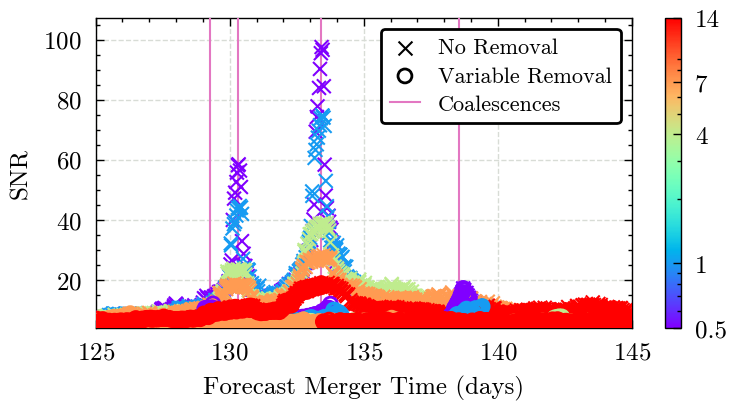

In [4]:
fig_focused_predict, _ = plotting_utils.plot_around_time(
    results_one=results_noremoval,
    results_two=results_varremoval,
    truth_times=truth_times_s,
    times_before=times_before,
    label_one='No Removal',
    label_two='Variable Removal',
    start_time_offset=125,
    end_time_offset=145,
    legend_loc='upper right'
)
fig_focused_predict.savefig(f'plots/focused_results_prediction.pdf')


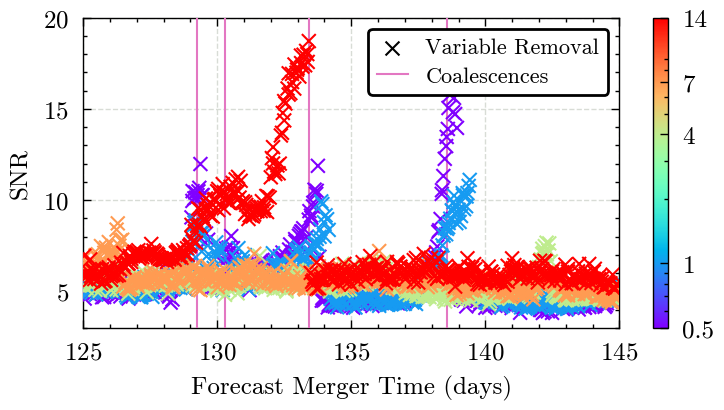

In [5]:
fig_focused_predict_varonly, _ = plotting_utils.plot_around_time(
    results_one=results_varremoval,
    truth_times=truth_times_s,
    times_before=times_before,
    label_one='Variable Removal',
    start_time_offset=125,
    end_time_offset=145,
    legend_loc='upper right'
)
_[0].set_ylim(3,20)

fig_focused_predict.savefig(f'plots/focused_results_prediction.pdf')

/local/gareth.cabourndavies/ipykernel_2138268/2545874310.py:17: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax_focused_dataend.legend(loc='upper left')


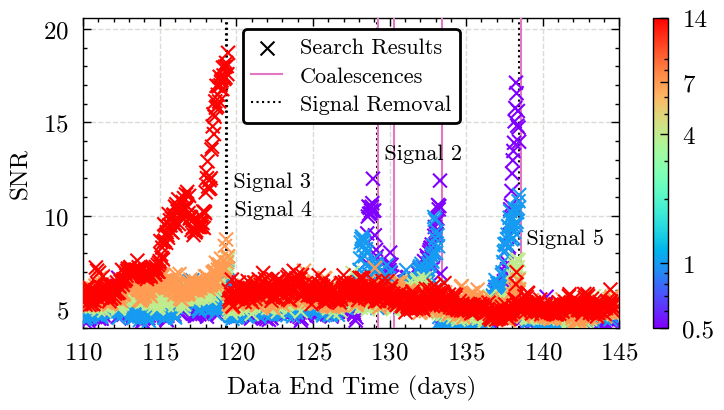

In [6]:
fig_focused_dataend, (ax_focused_dataend, labels, lines) = plotting_utils.plot_around_time(
    results_one=results_varremoval,
    times_before=times_before,
    truth_times=truth_times_s,
    label_one='Search Results',
    predicted_time=False,
    start_time_offset=110,
    end_time_offset=145,
)
# Signal 3 is removed 11 days premerger
lines.append(ax_focused_dataend.axvline(
    0,
    c='k',
    linestyle=':'
))
labels.append('Signal Removal')
ax_focused_dataend.legend(loc='upper left')
for signal_number, time_before in zip([2,3,4,5], [7200, 11*86400, 14*86400, 7200]):
    ax_focused_dataend.axvline(
        (truth_times_s[signal_number] - time_before) / 86400,
        c='k',
        linestyle=':'
    )
    ax_focused_dataend.text(
        (truth_times_s[signal_number] - time_before) / 86400,
        16-signal_number*1.5,
        f' Signal {signal_number}', 
        fontsize=8,
        zorder=40
    )
leg = ax_focused_dataend.legend(
    handles=lines,
    labels=labels,
    loc='upper center',
    framealpha=1,
    frameon=True,
    edgecolor='k'
)
leg.set_zorder(50)
fig_focused_dataend.savefig(f'plots/focused_results_data_end_time.pdf')
fig_focused_dataend.savefig(f'{paper_plots_dir}/figure_X_focused_region_variable_removal.png')